[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lasseufpa/ic/blob/main/ic/notebooks/13_1_RAG.ipynb)


# EC1036 - Inteligência Computacional 
## Tópico: Retrieval Augmented Generation

*OBS: Esse notebook foi desenvolvido para ser executado no ambiente do google colab*

## Bibliotecas python utilizadas

In [ ]:
#Descomente a linha abaixo e instale as bibliotecas necessárias para rodar o notebook
#&pip install -q langchain langchain-openai chromadb langchain_community langchain-text-splitters langchain-core faiss-cpu langchain_huggingface sentence-transformers huggingface_hub

### Caso possua uma api key da open ai

Se possuir uma key da openai insira no colab no campo secrets e descomente os códigos

In [ ]:
#from google.colab import userdata
#key = userdata.get('api_key') #adiciona a API key da openai

## O que é RAG (Retrieval Augmented Generation)?

RAG, ou Geração Aumentada por Recuperação, é uma técnica que combina a capacidade de modelos de linguagem grandes (LLMs) de gerar texto com a habilidade de recuperar informações relevantes de uma base de conhecimento externa.

Tradicionalmente, LLMs são treinados em vastos volumes de dados, mas seu conhecimento é estático e limitado ao que foi visto durante o treinamento. Quando confrontados com perguntas que exigem informações muito específicas, atualizadas ou privadas, eles podem 'alucinar' (gerar informações incorretas ou inventadas).

Mais detalhadamente, a RAG é uma técnica que transforma modelos de linguagem de uso geral, como GPT, em assistentes mais úteis e informados. Funciona como um sistema que busca informações de uma base de conhecimento, como uma grande biblioteca digital, para responder perguntas ou atender solicitações específicas.

O RAG resolve esse problema adicionando uma etapa de 'recuperação' antes da 'geração'. Funciona assim:

1.  **Consulta (Query):** O usuário faz uma pergunta.
2.  **Recuperação (Retrieval):** A pergunta é usada para buscar (retrieval) documentos ou trechos de texto relevantes de uma base de conhecimento (como um banco de dados de vetores, documentos locais, etc.).
3.  **Aumento (Augmentation):** Os trechos recuperados são então fornecidos ao LLM como contexto adicional, 'aumentando' o prompt original.
4.  **Geração (Generation):** O LLM usa esse contexto aumentado para gerar uma resposta mais precisa, informada e fundamentada nas fontes fornecidas.

**Benefícios do RAG:**

*   **Redução de Alucinações:** As respostas são ancoradas em fatos reais da base de conhecimento.
*   **Acesso a Dados Específicos/Privados:** Permite que o LLM utilize informações que não estavam em seu treinamento original.
*   **Atualização Fácil:** A base de conhecimento pode ser atualizada independentemente do LLM.
*   **Transparência:** É possível citar as fontes e mostrar de onde a informação foi recuperada.


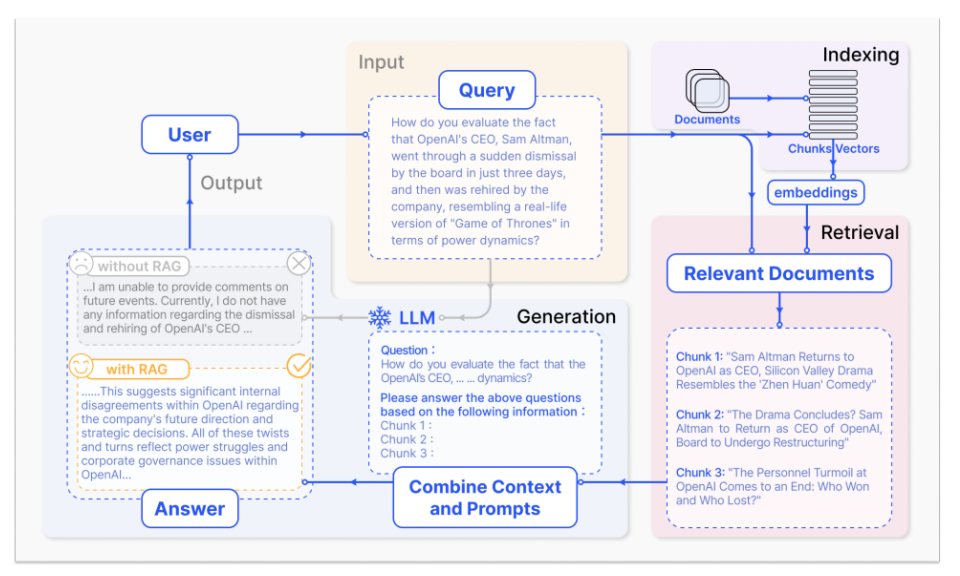

# 1 - Retrieval (Recuperação)

O Retrieval é o processo de buscar em uma base de dados externa (sua base de documentos) os fragmentos de texto mais relevantes para uma determinada pergunta.

Imagine que o LLM é um estudante fazendo uma prova de "livro consulta". Ele não decorou todo o conteúdo (o conhecimento dele é limitado à data em que foi treinado), mas ele tem acesso a uma biblioteca imensa. O Retrieval é o bibliotecário que corre até as estantes, seleciona os 3 ou 5 parágrafos que contêm a resposta e os entrega ao estudante.

## Preparação da Base de Conhecimento e Chunking


Antes de qualquer consulta, precisamos preparar a base de conhecimento que o RAG irá utilizar. Isso envolve:

1.  **Definir a Base de Conhecimento:** Qual texto ou conjunto de documentos contém as informações que queremos que o LLM acesse.
2.  **Chunking (Segmentação):** Dividir esses documentos maiores em pedaços menores (chunks). Chunks muito grandes podem 'afogar' o LLM com informações irrelevantes, enquanto chunks muito pequenos podem perder o contexto necessário. A escolha do tamanho do chunk e do overlap é crucial.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

def visualize_rag_chunks(text, chunk_size, chunk_overlap):
    chunks = []
    start = 0

    # Lógica de split simples (por caracteres)
    if chunk_size <= 0: return

    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - chunk_overlap
        if start >= len(text) or chunk_size <= chunk_overlap:
            break

    # Montagem do HTML para visualização
    colors = ["#FFD700", "#87CEFA", "#90EE90", "#FFB6C1", "#FFA07A"]
    html_output = "<h3>Visualização dos Chunks:</h3><div style='line-height: 2.5;'>"

    for i, chunk in enumerate(chunks):
        color = colors[i % len(colors)]
        html_output += f"<mark style='background-color: {color}; padding: 5px; border-radius: 4px; margin-right: 5px;'>[{chunk}]</mark> "

    html_output += "</div>"
    html_output += f"<p><b>Total de chunks:</b> {len(chunks)}</p>"
    display(HTML(html_output))

# Texto de exemplo
exemplo_texto = "O Retrieval-Augmented Generation (RAG) combina a recuperação de documentos com modelos de linguagem para gerar respostas precisas."

# Widgets interativos
widgets.interact(
    visualize_rag_chunks,
    text=widgets.Textarea(value=exemplo_texto, description='Texto:', layout={'width': '90%'}),
    chunk_size=widgets.IntSlider(min=5, max=100, step=1, value=30, description='Chunk Size:'),
    chunk_overlap=widgets.IntSlider(min=0, max=50, step=1, value=10, description='Overlap:')
);

interactive(children=(Textarea(value='O Retrieval-Augmented Generation (RAG) combina a recuperação de document…

## Utilizando o RecursiveCharacterTextSplitter do Langchain

Diferente de um split simples que corta o texto a cada "X" caracteres (o que fatalmente cortaria palavras ao meio e destruiria o sentido), este divisor é inteligente e recursivo. O `RecursiveCharacterTextSplitter` tenta dividir o texto em pedaços menores de forma mais inteligente, priorizando quebras em parágrafos ou frases completas, para manter o máximo de contexto possível em cada chunk.

* Preservação Semântica: Ele utiliza uma lista hierárquica de separadores (como \n\n, \n, . e ). Ele tenta manter parágrafos juntos, depois frases e, por fim, palavras.

* Eficiência de Busca: Ao manter frases completas dentro de um chunk, o Embedding (representação matemática do texto) consegue capturar muito melhor o significado daquela informação.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
from langchain_text_splitters import RecursiveCharacterTextSplitter

def visualize_langchain_chunks(text, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", " ", ""]
    )

    docs = splitter.create_documents([text])
    chunks = [doc.page_content for doc in docs]

    colors = ["#FFD700", "#87CEFA", "#90EE90", "#FFB6C1", "#FFA07A"]
    html_output = "<h3>Visualização LangChain:</h3><div style='line-height: 2.5;'>"

    for i, content in enumerate(chunks):
        color = colors[i % len(colors)]
        display_text = content.replace("\n", " ↵ ")
        html_output += f"<mark style='background-color: {color}; padding: 5px; border-radius: 4px; margin-right: 5px; border: 1px solid #555;'>{display_text}</mark> "

    html_output += "</div>"
    html_output += f"<p style='margin-top:15px;'><b>Total de chunks:</b> {len(chunks)}</p>"
    display(HTML(html_output))

exemplo_rag = """O RAG resolve o problema de alucinação dos LLMs.
Primeiro, ele recupera dados externos relevantes.
Depois, ele anexa esses dados ao prompt do usuário.
Finalmente, o modelo gera uma resposta baseada apenas nesses dados."""

widgets.interact(
    visualize_langchain_chunks,
    text=widgets.Textarea(value=exemplo_rag, description='Texto:', layout={'width': '90%', 'height': '100px'}),
    chunk_size=widgets.IntSlider(min=10, max=200, step=5, value=80, description='Size:'),
    chunk_overlap=widgets.IntSlider(min=0, max=100, step=5, value=20, description='Overlap:')
);

interactive(children=(Textarea(value='O RAG resolve o problema de alucinação dos LLMs.\nPrimeiro, ele recupera…

## Indexação e Algoritmos de busca

A etapa de **Indexação** é o processo de "preparação do terreno". Imagine que você tem milhares de livros, mas precisa que eles sejam encontrados em milissegundos. Indexar é organizar essa biblioteca de forma que o computador não precise ler tudo toda vez que o usuário fizer uma pergunta. **Tecnicamente, a indexação é o processo de transformar dados não estruturados (texto) em uma estrutura de dados pesquisável e otimizada (vetores).**




## Modelo de embeddings


Para que o computador consiga "ler" e comparar os textos de forma eficiente, ele não utiliza palavras, mas sim números. Um Embedding é uma representação numérica de um conceito em forma de **vetor** (uma lista de números decimais). Essa técnica transforma os pedaços de texto separados na etapa de chunking em vetores de números, projetados em um sistema multidimensional que agrupa esses vetores por semelhança semântica.

O processo de transformação segue este fluxo:

1. **Modelo de Embedding:** Utilizamos um modelo de IA especializado (como os da OpenAI, HuggingFace) que foi treinado em bilhões de frases para entender relações entre palavras.

2. **Vetorização:** O texto do seu chunk é passado por esse modelo, que gera uma lista fixa de números.

3. **Vector Store** (Banco de Dados de Vetores): Esses números são armazenados em bancos de dados especiais (como ChromaDB, Pinecone ou FAISS).

Matematicamente, o texto $T$ é mapeado para um espaço vetorial $V$ através de uma função de embedding $f$:

$$f(T) = [v_1, v_2, v_3, ..., v_n]$$

Neste espaço, a proximidade geométrica representa a similaridade semântica. Se dois chunks tratam do mesmo assunto, a distância euclidiana entre seus vetores será pequena.


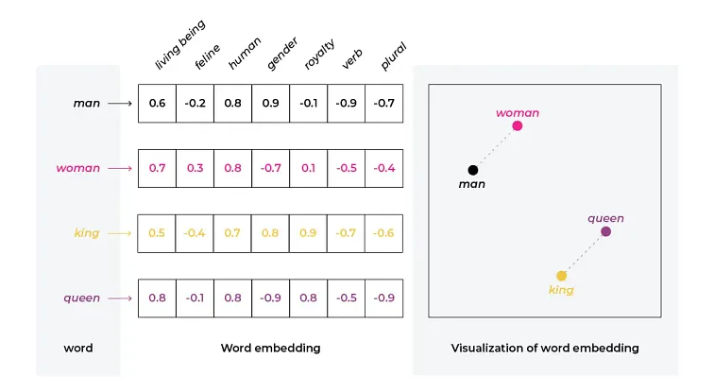

 ## Armazenamento e Estruturas de Dados (Vector Store)

Um vector store é um banco de dados especializado que armazena os embeddings e permitir buscas de similaridade eficientes. Para isso os vector databases utilizam algoritmos de Approximate Nearest Neighbors (ANN) que priorizam desempenho e escalabilidade em vez de precisão exata, como por exemplo,HNSW (Hierarchical Navigable Small Worlds) e  IVF (Inverted File Index).

> *OBS: Em grandes escalas, encontrar o "vizinho mais próximo exato" (kNN) é matematicamente exaustivo ($O(N)$). O ANN aceita trocar um pouco de precisão por uma velocidade de busca maior.*

Durante a indexação, não salvamos apenas o vetor. Criamos um objeto de dados que contém:

* ID: Identificador único.

* Vector: O embedding numérico.

* Payload/Metadata: O texto original do chunk e informações extras (ex: número da página do PDF, data de criação, autor).

Importância técnica: Isso permite realizar Busca Híbrida. Você pode filtrar por metadados (ex: "buscar apenas em documentos de 2023") antes ou depois de realizar a busca vetorial por significado.

---

**Busca por Similaridade:**

Ao realizar a consulta, o vector database utiliza métricas como a similaridade do cosseno ou a distância Euclidiana para encontrar os vetores mais próximos ao vetor de consulta. Em um espaço altamente dimensional, palavras ou conceitos com significado ou grafia semelhantes tendem a ficar próximos entre si, enquanto conceitos diferentes ficam mais distantes, pois cada palavra ocupa um ponto único nessa representação vetorial. Assim, métricas de similaridade podem ser usadas para determinar quais palavras, frases ou documentos são mais relevantes para o contexto da sequência de entrada.

<br>

**Similaridade do cosseno:**
$$\text{sim}(A, B) = \frac{A \cdot B}{||A|| \cdot ||B||} $$
Essa métrica mede o ângulo entre dois vetores, ignorando sua magnitude. Quanto mais próximo de 1 for o resultado, maior é a similaridade semântica entre os vetores.

<br>

**Distância Euclidiana**:

$$d(A,B)=||A-B||^{2}$$
A distância Euclidiana mede a distância direta entre dois pontos no espaço vetorial. Quanto menor o valor obtido, mais próximos os vetores estão e, consequentemente, maior é a similaridade entre os itens representados. Essa métrica é especialmente útil quando a magnitude dos vetores também carrega informação relevante.

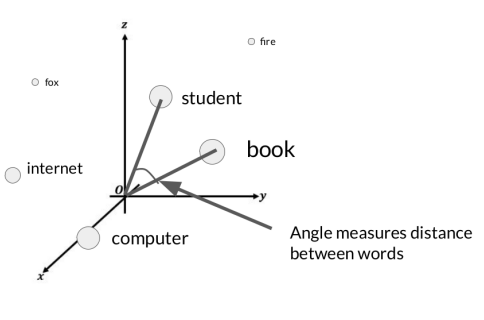

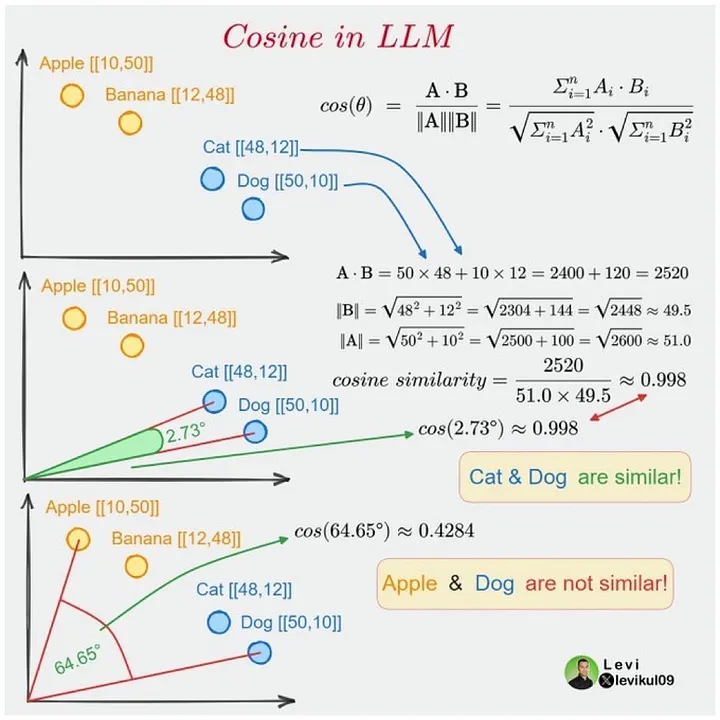

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Inicializando o modelo open-source
# O 'all-MiniLM-L6-v2' é rápido e eficiente para rodar localmente
model_name = "sentence-transformers/all-MiniLM-L6-v2"
model_kwargs = {'device': 'cuda'} # Mude para 'cuda' se tiver GPU ou 'cpu'
encode_kwargs = {'normalize_embeddings': False}

embeddings_model = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

# Transformar as palavras em vetores
# Nota: O método embed_query continua o mesmo
vetor_cat = embeddings_model.embed_query("cat")
vetor_dog = embeddings_model.embed_query("dog")
vetor_apple = embeddings_model.embed_query("apple")

# Calcular a similaridade
def calcular_sim(v1, v2):
    return cosine_similarity([v1], [v2])[0][0]

sim_dog_cat = calcular_sim(vetor_dog, vetor_cat)
sim_dog_apple = calcular_sim(vetor_dog, vetor_apple)

print(f"Modelo utilizado: {model_name}")
print(f"Similaridade dog -> cat: {sim_dog_cat:.4f}")
print(f"Similaridade dog -> apple: {sim_dog_apple:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo utilizado: sentence-transformers/all-MiniLM-L6-v2
Similaridade dog -> cat: 0.6606
Similaridade dog -> apple: 0.2918


## Exemplos de Approximate Nearest Neighbors

### HNSW (Hierarchical Navigable Small Worlds)

O **HNSW** é um algoritmo de ANN que combina dois conceitos fundamentais: Skip Lists (listas de salto) e Navigable Small Worlds (mundos pequenos navegáveis). Ele é amplamente considerado o estado da arte para indexação vetorial devido ao seu equilíbrio entre latência de busca, precisão e escalabilidade.

A **Skip List** é uma estrutura de dados probabilística que permite buscas rápidas em uma lista ordenada, funcionando de forma análoga a uma busca binária, mas sem a rigidez de uma árvore. Imagine uma lista comum onde, para chegar ao número 90, você precisaria passar por todos os anteriores. Na Skip List, criamos "camadas de expressas" acima da lista principal. Na camada mais alta, você dá saltos largos (ex: de 10 em 10 ou 50 em 50); ao perceber que passou do alvo, você desce um nível para refinamentos menores.

Já os **Navigable Small Worlds** baseiam-se na teoria do "mundo pequeno", que sugere que qualquer nó em um grafo pode ser alcançado em poucos passos partindo de qualquer outro nó. Tecnicamente, isso é alcançado garantindo que cada nó tenha conexões locais (com vizinhos imediatos) e algumas conexões de longo alcance (com nós distantes). Em um espaço vetorial, isso permite que o algoritmo use uma "busca gananciosa" (greedy search): ele sempre pula para o vizinho mais próximo da consulta final. O problema original dos Small Worlds era que, em bases muito grandes, a busca ainda podia se tornar ineficiente; o HNSW resolve isso aplicando a lógica de hierarquia das Skip Lists sobre esses grafos de mundos pequenos.

<br>

**A Estrutura de Grafo Hierárquico:**
Diferente de índices planos que realizam buscas exaustivas, o HNSW constrói uma estrutura de múltiplas camadas ($L_0, L_1, ..., L_n$).

* Camadas Superiores (Esparsas): Contêm apenas alguns pontos de dados (nós). Os saltos entre esses nós cobrem grandes distâncias no espaço vetorial multidimensional.

* Camadas Inferiores (Densas): À medida que descemos nas camadas, a densidade de nós aumenta. A camada base ($L_0$) contém todos os vetores indexados.

<br>

A busca inicia-se na camada mais alta $L_{n}$, então algoritmo avalia os vizinhos do nó atual e salta para aquele que for matematicamente mais próximo do vetor de consulta (query vector). Quando não há mais vizinhos próximos na camada atual, o algoritmo desce para o nó correspondente na camada imediatamente abaixo. Esse processo se repete de forma recursiva até atingir a camada $L_0$. Na camada base, o algoritmo realiza uma busca mais detalhada para encontrar os $k$ vizinhos mais próximos. Esse mecanismo reduz a complexidade da busca de $O(N)$ para $O(\log N)$, permitindo consultas em milissegundos mesmo em bases com milhões de documentos.


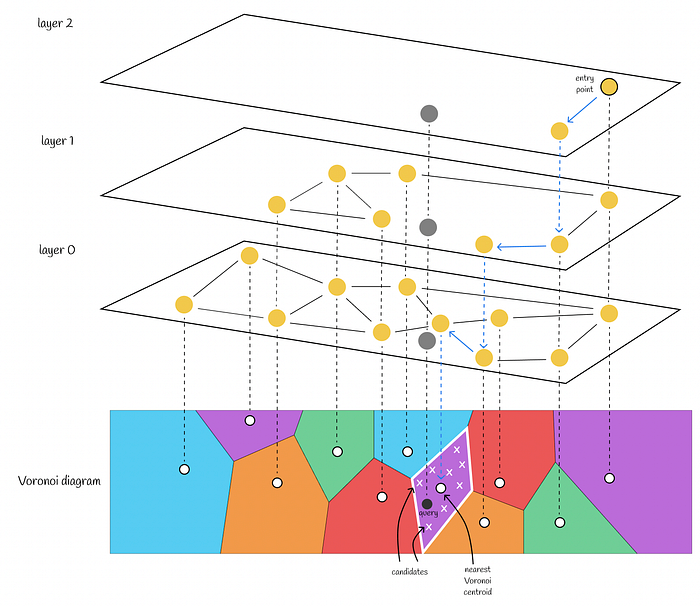

### IVF (Inverted File Index)

O **IVF** é um algoritmo de indexação que visa reduzir o tempo de busca ao limitar o número de vetores que precisam ser comparados com a consulta. Ele faz isso particionando o espaço vetorial em regiões distintas, de forma que o sistema só precise "olhar" para as regiões onde há maior probabilidade de encontrar a resposta.

Enquanto o HNSW foca na estrutura de grafos, o IVF baseia-se na partição do espaço vetorial através de quantização e agrupamento (clustering).


Em vez de uma busca exaustiva, o IVF organiza os vetores de modo que apenas uma pequena fração da base de dados seja analisada, para isso ele requer uma fase de treinamento. Durante este estágio, o algoritmo utiliza o K-Means para analisar a distribuição dos vetores no espaço multidimensional.O algoritmo define $K$ pontos centrais chamados centróides em que cada um representa o "centro de massa" de uma região específica do espaço vetorial.

<br>

Quando uma consulta chega ao sistema, o processo técnico ocorre em duas etapas:

1. Busca de Centróide: O vetor da consulta é comparado com os centróides para identificar qual célula é a mais próxima.

2. Busca Local: O algoritmo realiza uma busca exaustiva (comparação direta) apenas com os vetores que estão dentro das células selecionadas.

----
Hiperparâmetro crítico: `nprobr` e `k`
* `nprobr`: Se `nprobe=1`, o algoritmo busca apenas na célula mais próxima. Isso é extremamente rápido, mas se o resultado real estiver logo após a "fronteira" da célula vizinha, ele será ignorado (erro de busca). Aumentar o nprobe (ex: `nprobe=10`) faz com que o algoritmo pesquise nas 10 células mais próximas, aumentando a precisão ao custo de um pouco mais de tempo de processamento.

* `k`: O número de centróides criados no treinamento. Se for muito baixo, cada cluster terá vetores demais e a busca será lenta. Se for muito alto, a busca pelos centróides em si demora e o treino fica pesado.

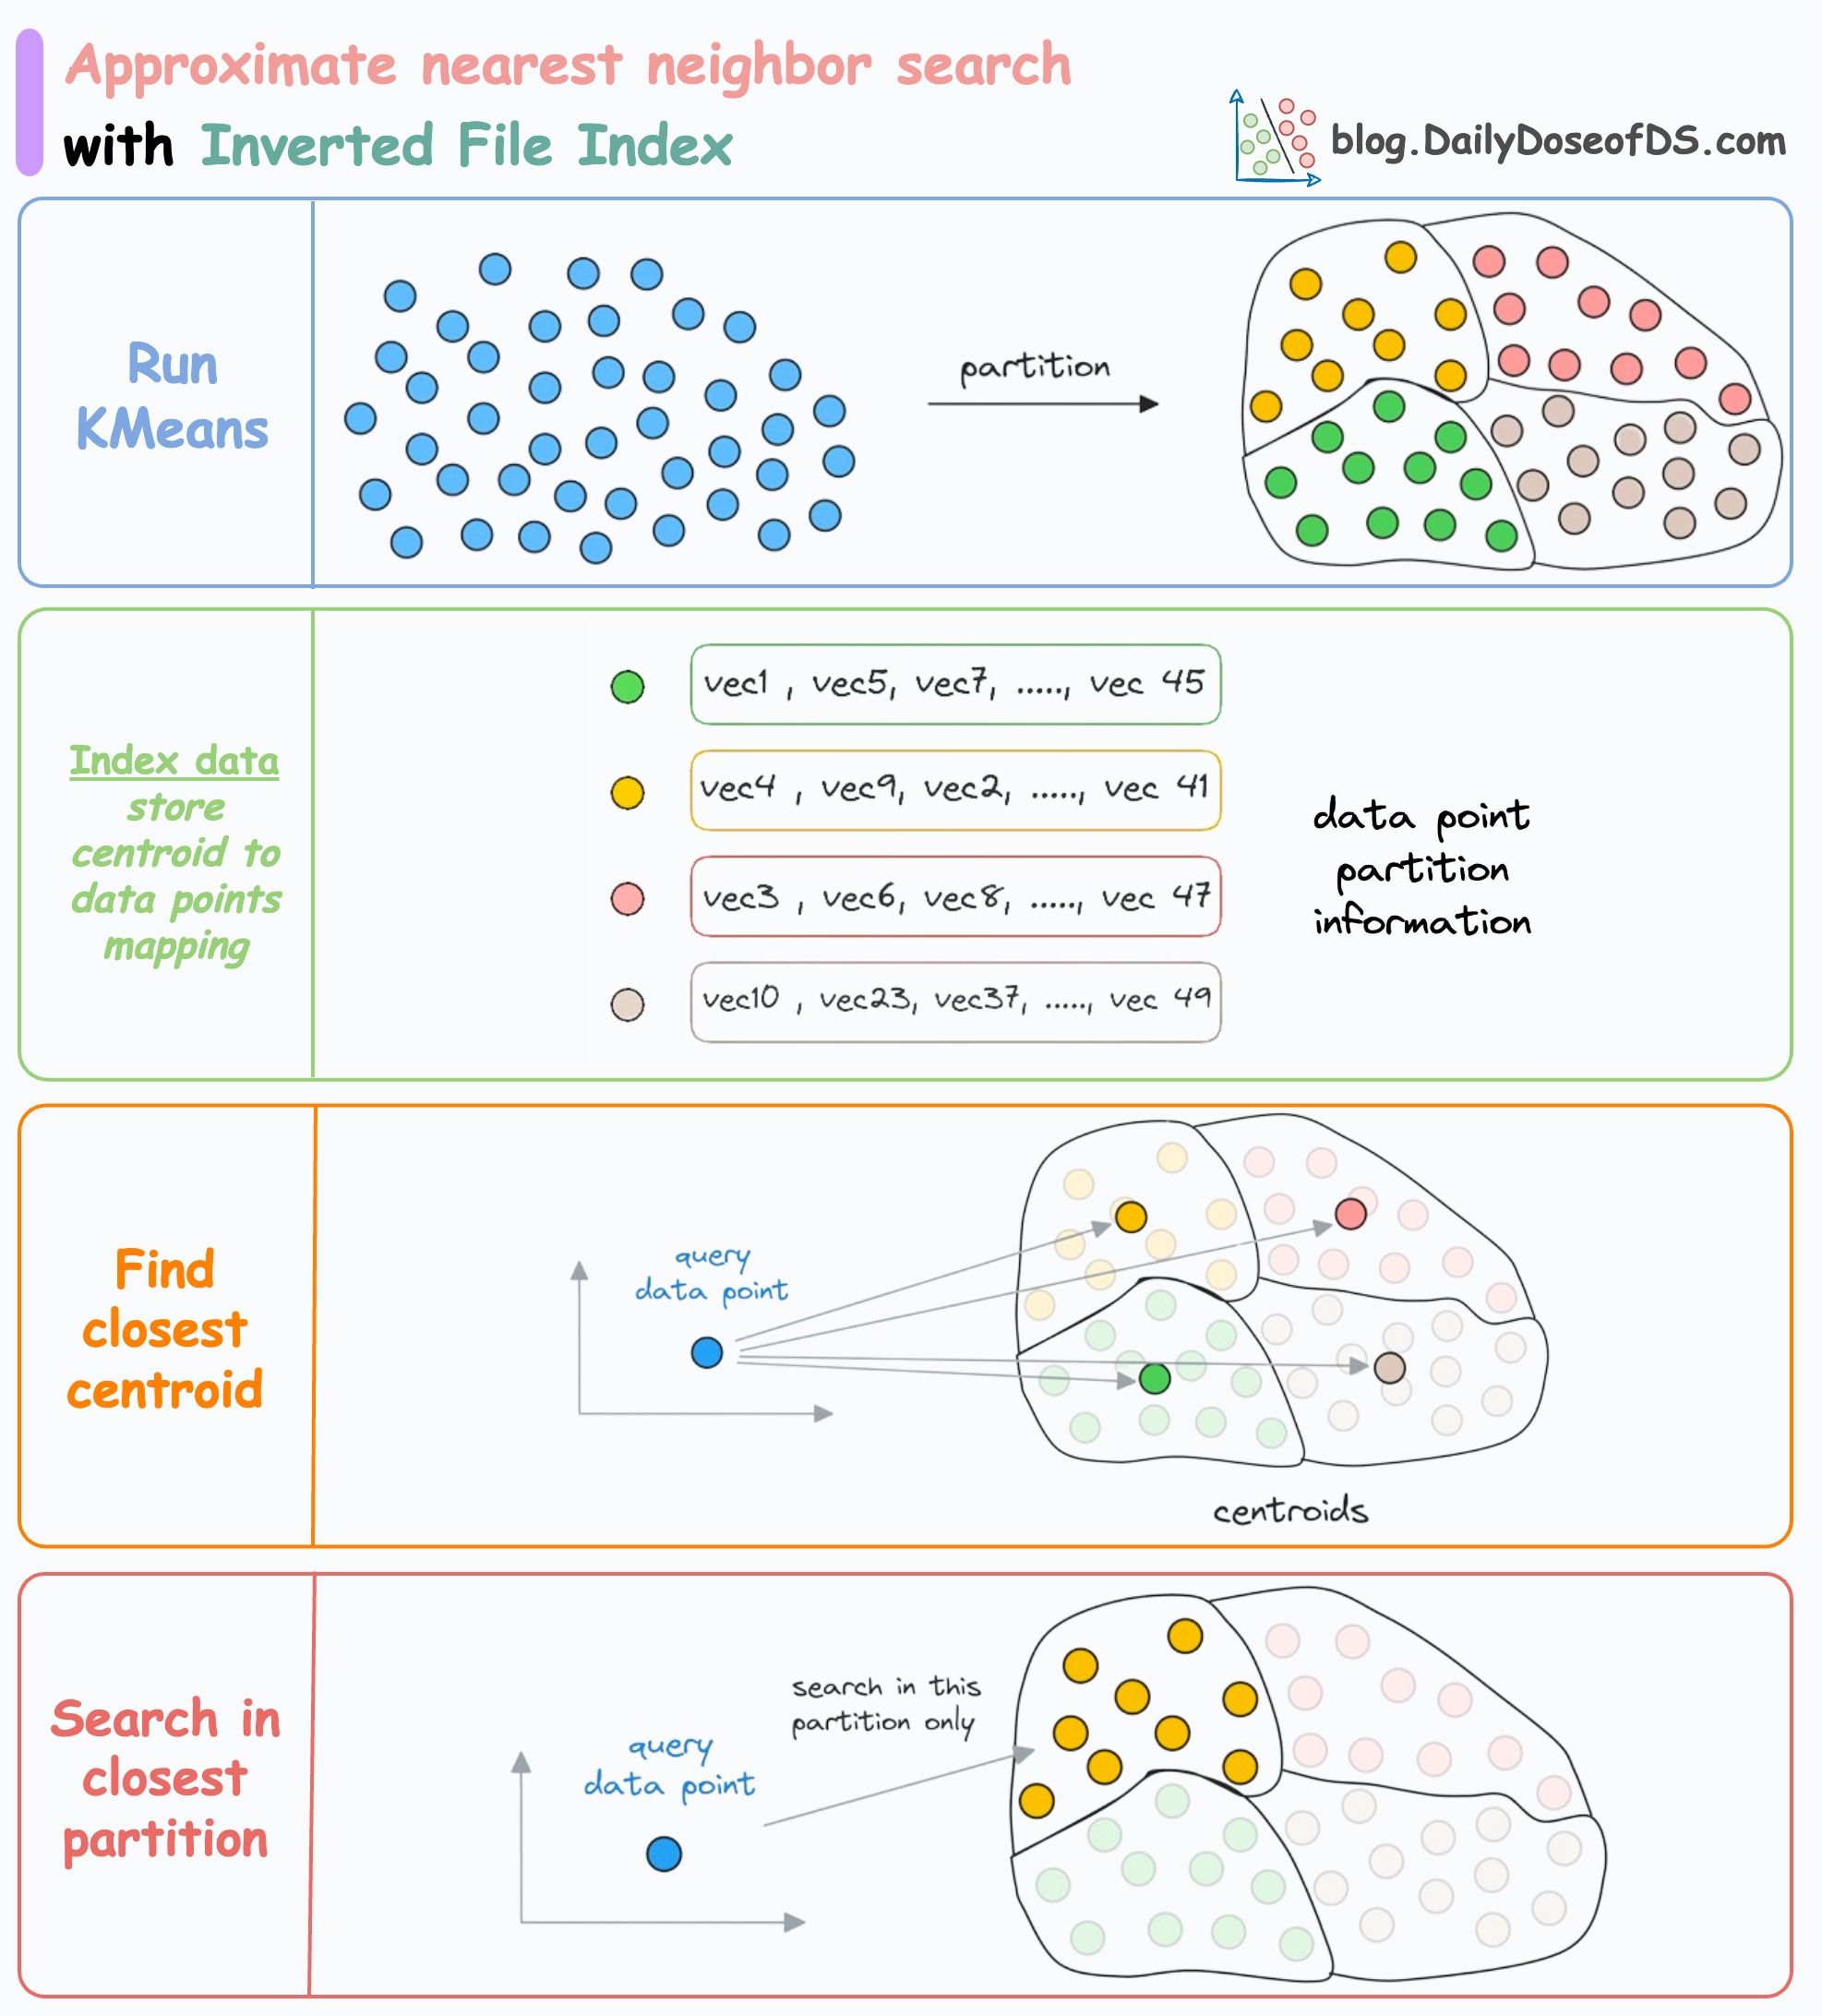

# 2 - Augmentation

A **augmentation** é o processo de preparar e enriquecer o "Context Window" (janela de contexto) do LLM. No fluxo tradicional de um chat, o modelo recebe apenas a pergunta do usuário. No RAG, nós aumentamos essa entrada, injetando nela os fragmentos de texto que foram encontrados durante a etapa de Retrieval.

O objetivo é transformar uma pergunta genérica em uma instrução rica e fundamentada em contexto.

<br>

<font size="5">Template do prompt:</font>

Essa etapa não consiste apenas em "jogar" o texto de qualquer jeito. Nós utilizamos um Template de Prompt que instrui o modelo sobre como ele deve usar as informações fornecidas. Geralmente, o prompt aumentado segue esta estrutura:

* **Instrução de Sistema:** "Você é um assistente prestativo. Use apenas o contexto fornecido para responder."

* **Contexto Recuperado:** O conteúdo dos N chunks que seu banco de vetores retornou.

* **Histórico (opcional):** Conversas anteriores para manter a coerência.

* **Pergunta do Usuário:** A dúvida atual que precisa de resposta.

<br>

<font size="5">Desafios Técnicos:</font>


Embora pareça simples, essa etapa exige atenção a alguns detalhes técnicos:

* **Context Window Limit:** Cada modelo (como GPT-4 ou Llama 3) tem um limite de tokens. Se recuperarmos chunks demais, o prompt pode exceder esse limite.

* [**Lost in the Middle**](https://arxiv.org/abs/2307.03172): Estudos mostram que LLMs tendem a dar mais atenção às informações no início e no fim do contexto, às vezes ignorando o que está no meio. Por isso, a ordem de relevância dos chunks importa.

* **Irrelevância:** Se o Retrieval trouxer informações erradas, a etapa de aumentação acabará "poluindo" o raciocínio do modelo.

In [ ]:
from langchain_core.prompts import PromptTemplate

# Note as variáveis entre chaves {context} e {question}
template_rag = """Você é um assistente virtual especializado em suporte técnico.
Use os fragmentos de contexto abaixo para responder à pergunta do usuário.
Se você não souber a resposta com base no contexto, apenas diga que não sabe, não tente inventar uma resposta.

---
CONTEXTO:
{context}
---

PERGUNTA: {question}

RESPOSTA ÚTIL:"""

# Criando o objeto PromptTemplate
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template=template_rag
)

# Simulando dados vindo do Retrieval (Busca Vetorial)
chunks_recuperados = [
    "O sistema de backup automático ocorre todos os dias às 03:00 da manhã.",
    "Os arquivos são armazenados em um servidor seguro em nuvem com criptografia AES-256."
]

contexto_formatado = "\n\n".join(chunks_recuperados)

pergunta_usuario = "Quando e como os backups são feitos?"

prompt_final = prompt.format(
    context=contexto_formatado,
    question=pergunta_usuario
)

print(prompt_final)

Você é um assistente virtual especializado em suporte técnico.
Use os fragmentos de contexto abaixo para responder à pergunta do usuário.
Se você não souber a resposta com base no contexto, apenas diga que não sabe, não tente inventar uma resposta.

---
CONTEXTO:
O sistema de backup automático ocorre todos os dias às 03:00 da manhã.

Os arquivos são armazenados em um servidor seguro em nuvem com criptografia AES-256.
---

PERGUNTA: Quando e como os backups são feitos?

RESPOSTA ÚTIL:


#3 - Generation

A fase de Generation (Geração) é o ato final do pipeline RAG. É o momento em que o LLM assume o papel, processando o prompt para produzir uma resposta coerente, fluida e, acima de tudo, ancorada nos dados recuperados. Enquanto as etapas anteriores focam em encontrar e organizar a informação, a geração foca em comunicação e síntese.

<font size="5">Hiperparâmetros de Controle:</font>

* **Temperatura:** Controla a criatividade. Para RAG, geralmente usamos valores baixos (entre 0.1 e 0.3) para garantir que o modelo seja factual e não invente variações linguísticas desnecessárias.

* **Max Tokens:** Define o tamanho máximo da resposta.



## Ferramentas e APIs para RAG

Essas bibliotecas permitem criar o pipeline completo, desde o carregamento do PDF até a resposta final, com poucas linhas de código.

* LangChain: A biblioteca mais popular. É extremamente versátil e possui integrações com quase todas as ferramentas de IA existentes. É excelente para criar fluxos complexos (chains) e agentes autônomos.

* LlamaIndex: Focada especificamente em indexação e recuperação de dados. Se o seu desafio principal é lidar com grandes volumes de documentos complexos e variados, o LlamaIndex costuma ser mais eficiente e direto que o LangChain.

---
Bancos de Dados Vetoriais:

* ChromaDB: Fácil de instalar e roda inteiramente na memória ou disco local.

* Pinecone: Um serviço gerenciado (SaaS) na nuvem. É a escolha preferida para sistemas em produção que precisam escalar para bilhões de vetores sem que você precise gerenciar servidores.

* FAISS (Facebook AI Similarity Search): Uma biblioteca de baixo nível desenvolvida pela Meta. É incrivelmente rápida para buscas em larga escala, mas exige mais configuração manual.

---

Provedores de Modelos:

* OpenAI (GPT-4 / Text-Embedding-3): O padrão da indústria pela facilidade de uso e alta qualidade, porém com custos de API.

* Hugging Face: Permite baixar modelos como o Llama 3 ou modelos de embedding locais para rodar sem custo de API (usando a GPU própria).

# RAG na prática

In [ ]:
#!pip install -q langchain langchain-openai chromadb langchain_community langchain-text-splitters langchain-core faiss-cpu langchain_huggingface

In [ ]:
# =========================
# Instalação de libs
# =========================
import requests
import uuid
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.vectorstores import FAISS
import faiss
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.docstore import InMemoryDocstore
from langchain_huggingface import HuggingFaceEmbeddings
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, AutoConfig
from langchain_huggingface import HuggingFacePipeline
from langchain_core.output_parsers import StrOutputParser
import numpy as np
import re
import torch

## Escolhendo a base de dados

In [ ]:
# Coleta de dado externo (Machado de Assis)
url = "https://raw.githubusercontent.com/grovina/assisnet/refs/heads/master/casmurro.txt"
texto_bruto = requests.get(url).text
trecho_livro = texto_bruto[0:10000] # Pegamos um trecho específico para o teste (Capítulos iniciais)
trecho_livro

"\ufeffI\r\n\r\nDo titulo.\r\n\r\nUma noite destas, vindo da cidade para o Engenho Novo, encontrei no\r\ntrem da Central um rapaz aqui do bairro, que eu conheço de vista e\r\nde chapéo. Comprimentou-me, sentou-se ao pé de mim, falou da lua e\r\ndos ministros, e acabou recitando-me versos. A viagem era curta, e os\r\nversos póde ser que não fossem inteiramente maus. Succedeu, porém, que\r\ncomo eu estava cançado, fechei os olhos tres ou quatro vezes; tanto\r\nbastou para que elle interrompesse a leitura e mettesse os versos no\r\nbolso.\r\n\r\n--Continue, disse eu accordando.\r\n\r\n--Já acabei, murmurou elle.\r\n\r\n--São muito bonitos.\r\n\r\nVi-lhe fazer um gesto para tiral-os outra vez do bolso, mas não passou\r\ndo gesto; estava amuado. No dia seguinte entrou a dizer de mim nomes\r\nfeios, e acabou alcunhando-me _Dom Casmurro._ Os visinhos, que não\r\ngostam dos meus habitos reclusos e calados, deram curso á alcunha, que\r\nafinal pegou. Nem por isso me zanguei. Contei a anecdota a

In [ ]:
def limpar_texto(texto):
    # Remove o caractere \ufeff (BOM - Byte Order Mark)
    texto = texto.replace('\ufeff', '')

    # Normaliza quebras de linha (substitui \r\n por \n)
    texto = texto.replace('\r\n', '\n')

    # Remove excesso de espaços em branco e linhas vazias múltiplas
    texto = re.sub(r'\n\s*\n', '\n\n', texto)

    # Remove caracteres especiais de formatação de livros (como os underscores de itálico)
    texto = texto.replace('_', '')

    return texto.strip()

# Aplicando no seu código:
texto_limpo = limpar_texto(texto_bruto)
trecho_livro = texto_limpo[0:10000]
trecho_livro

"I\n\nDo titulo.\n\nUma noite destas, vindo da cidade para o Engenho Novo, encontrei no\ntrem da Central um rapaz aqui do bairro, que eu conheço de vista e\nde chapéo. Comprimentou-me, sentou-se ao pé de mim, falou da lua e\ndos ministros, e acabou recitando-me versos. A viagem era curta, e os\nversos póde ser que não fossem inteiramente maus. Succedeu, porém, que\ncomo eu estava cançado, fechei os olhos tres ou quatro vezes; tanto\nbastou para que elle interrompesse a leitura e mettesse os versos no\nbolso.\n\n--Continue, disse eu accordando.\n\n--Já acabei, murmurou elle.\n\n--São muito bonitos.\n\nVi-lhe fazer um gesto para tiral-os outra vez do bolso, mas não passou\ndo gesto; estava amuado. No dia seguinte entrou a dizer de mim nomes\nfeios, e acabou alcunhando-me Dom Casmurro. Os visinhos, que não\ngostam dos meus habitos reclusos e calados, deram curso á alcunha, que\nafinal pegou. Nem por isso me zanguei. Contei a anecdota aos amigos da\ncidade, e elles, por graça, chamam-me as

In [ ]:
# Criação do documento com metadados
doc_original = Document(
    page_content=trecho_livro,
    metadata={"fonte": "Dom Casmurro", "autor": "Machado de Assis", "tipo": "Literatura"}
)

# Chunking (Segmentação)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ".", " ", ""]
)
chunks = text_splitter.split_documents([doc_original])
chunks[1]



Document(metadata={'fonte': 'Dom Casmurro', 'autor': 'Machado de Assis', 'tipo': 'Literatura'}, page_content='Do titulo.\n\nUma noite destas, vindo da cidade para o Engenho Novo, encontrei no\ntrem da Central um rapaz aqui do bairro, que eu conheço de vista e\nde chapéo. Comprimentou-me, sentou-se ao pé de mim, falou da lua e\ndos ministros, e acabou recitando-me versos. A viagem era curta, e os\nversos póde ser que não fossem inteiramente maus. Succedeu, porém, que\ncomo eu estava cançado, fechei os olhos tres ou quatro vezes; tanto\nbastou para que elle interrompesse a leitura e mettesse os versos no\nbolso.')

In [ ]:
# Verificando como ficaram os metadados
for i, chunk in enumerate(chunks):
    print(f"==============\nChunk {i}: {chunk}==============\n")

Chunk 0: page_content='I

Do titulo.' metadata={'fonte': 'Dom Casmurro', 'autor': 'Machado de Assis', 'tipo': 'Literatura'}==============

Chunk 1: page_content='Do titulo.

Uma noite destas, vindo da cidade para o Engenho Novo, encontrei no
trem da Central um rapaz aqui do bairro, que eu conheço de vista e
de chapéo. Comprimentou-me, sentou-se ao pé de mim, falou da lua e
dos ministros, e acabou recitando-me versos. A viagem era curta, e os
versos póde ser que não fossem inteiramente maus. Succedeu, porém, que
como eu estava cançado, fechei os olhos tres ou quatro vezes; tanto
bastou para que elle interrompesse a leitura e mettesse os versos no
bolso.' metadata={'fonte': 'Dom Casmurro', 'autor': 'Machado de Assis', 'tipo': 'Literatura'}==============

Chunk 2: page_content='--Continue, disse eu accordando.

--Já acabei, murmurou elle.

--São muito bonitos.' metadata={'fonte': 'Dom Casmurro', 'autor': 'Machado de Assis', 'tipo': 'Literatura'}==============

Chunk 3: page_content='Vi-lh

## Utilizando o modelo de embeddings

In [ ]:
#Definir o modelo de embedding
model_name = "sentence-transformers/all-MiniLM-L6-v2"
embeddings_model = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={'device': 'cuda'},
    encode_kwargs={'normalize_embeddings': False}
)

## Usando o Chomadb

In [ ]:
# Vetorização e Armazenamento (Limpando execuções anteriores com UUID)
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings_model,
    collection_name=f"aula_ic_{uuid.uuid4().hex[:8]}"
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [ ]:
def configurar_Qwen():
    model_id = "Qwen/Qwen2.5-3B-Instruct"

    # Carregando o Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

    # Carregando a configuração do modelo
    config = AutoConfig.from_pretrained(model_id, trust_remote_code=True)

    # Define o pad_token se não estiver definido, e atualiza a config do modelo
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = tokenizer.pad_token_id # Garante que a config do modelo tem pad_token_id

    # Carregando o Modelo com a configuração modificada
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        config=config, # Passa a configuração modificada
        dtype=torch.float32, # Usar 'dtype' em vez de 'torch_dtype'
        device_map="auto",
        trust_remote_code=True
    )

    # Criando o pipeline do Transformers
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=200,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id # Explicitly pass pad_token_id to the pipeline
    )

    # Integrando ao LangChain
    return HuggingFacePipeline(pipeline=pipe)

def comparar_metodos_Qwen(pergunta):
    # Inicializamos o Qwen localmente
    llm = configurar_Qwen()

    # --- MODO 1: SEM RAG ---
    # Para modelos locais, o invoke direto retorna a string
    resposta_sem_rag = llm.invoke(pergunta)

    # --- MODO 2: COM RAG ---
    docs_recuperados = retriever.invoke(pergunta)
    contexto_formatado = "\n".join([f"TRECHO {i}: {d.page_content}" for i, d in enumerate(docs_recuperados)])

    # Ajuste no Prompt:
    prompt_rag = ChatPromptTemplate.from_template("""
    Você é um assistente que responde APENAS com base no contexto abaixo.
    Se a informação não estiver no contexto, diga que não encontrou no texto.

    CONTEXTO:
    {context}

    PERGUNTA: {question}
    """)

    chain = prompt_rag | llm | StrOutputParser()
    resposta_com_rag = chain.invoke({"context": contexto_formatado, "question": pergunta})

    # --- EXIBIÇÃO DOS RESULTADOS ---
    print(f"\n PERGUNTA: {pergunta}")
    print("-" * 30)
    print(f" SEM RAG (Qwen Memória):\n{resposta_sem_rag}")
    print("-" * 30)
    print(f" COM RAG (Qwen + RAG):\n{resposta_com_rag}")
    print("-" * 30)
    print(f" CHUNKS RECUPERADOS: {len(docs_recuperados)} trechos.")

comparar_metodos_Qwen("Como o narrador justifica o título 'Dom Casmurro'?")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0



 PERGUNTA: Como o narrador justifica o título 'Dom Casmurro'?
------------------------------
 SEM RAG (Phi-2 Memória):
Como o narrador justifica o título 'Dom Casmurro'? - Resumo de Livro
Como o narrador justifica o título 'Dom Casmurro'?
O título "Dom Casmurro" é um jogo de palavras que se refere tanto ao personagem principal, Dom Casmurro, quanto à localização geográfica onde a história acontece. O narrador justifica o título em várias passagens do livro, explicando que o nome do personagem é uma referência ao lugar onde ele nasceu e cresceu.
No início da história, o narrador menciona que Dom Casmurro nasceu na cidade de Casimburgo, que é uma referência ao nome do personagem. Ele também destaca que a cidade é conhecida por sua riqueza mineral, o que é uma característica que se assemelha ao caráter do personagem.
Além disso, o narrador justifica o título ao descrever a natureza da cidade como um refú
------------------------------
 COM RAG (Phi-2 + RAG):
Human: 
    Você é um assiste

## Usando o FAISS

In [ ]:
# Gerar os embeddings primeiro (necessário para treinar o IVF)
embeddings_list = embeddings_model.embed_documents([c.page_content for c in chunks])
embeddings_matrix = np.array(embeddings_list).astype('float32')

# Configurar o índice IVF
dimension = embeddings_matrix.shape[1] #1536
nlist = 5  # Número de clusters
quantizer = faiss.IndexFlatL2(dimension)
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_L2)

# Treinar e Adicionar os vetores
# O IVF precisa de treino para posicionar os centroides dos clusters
index_ivf.train(embeddings_matrix)
index_ivf.add(embeddings_matrix)

# Crie docstore e index_to_docstore_id antes de criar o objeto FAISS
docstore = InMemoryDocstore()
index_to_docstore_id = {}

for i, chunk in enumerate(chunks):
    doc_id = str(uuid.uuid4())
    docstore.add({doc_id: chunk})
    index_to_docstore_id[i] = doc_id

# Criar o objeto FAISS do LangChain usando o índice já populado
vectorstore_faiss = FAISS(
    embedding_function=embeddings_model,
    index=index_ivf,
    docstore=docstore,
    index_to_docstore_id=index_to_docstore_id,
)

retriever_faiss = vectorstore_faiss.as_retriever(search_kwargs={"k": 3})


In [ ]:
def comparar_metodos_Qwen_faiss(pergunta):
    # Inicializamos o Qwen localmente
    llm = configurar_Qwen()

    # --- MODO 1: SEM RAG ---
    # Para modelos locais, o invoke direto retorna a string
    resposta_sem_rag = llm.invoke(pergunta)

    # --- MODO 2: COM RAG ---
    docs_recuperados = retriever_faiss.invoke(pergunta)
    contexto_formatado = "\n".join([f"TRECHO {i}: {d.page_content}" for i, d in enumerate(docs_recuperados)])

    # Ajuste no Prompt: Qwen funciona melhor com instruções diretas (QA)
    prompt_rag = ChatPromptTemplate.from_template("""
    Você é um assistente que responde APENAS com base no contexto abaixo.
    Se a informação não estiver no contexto, diga que não encontrou no texto.

    CONTEXTO:
    {context}

    PERGUNTA: {question}
    """)

    chain = prompt_rag | llm | StrOutputParser()
    resposta_com_rag = chain.invoke({"context": contexto_formatado, "question": pergunta})

    # --- EXIBIÇÃO DOS RESULTADOS ---
    print(f"\n PERGUNTA: {pergunta}")
    print("-" * 30)
    print(f" SEM RAG (Qwen Memória):\n{resposta_sem_rag}")
    print("-" * 30)
    print(f" COM RAG (Qwen + RAG):\n{resposta_com_rag}")
    print("-" * 30)
    print(f" CHUNKS RECUPERADOS: {len(docs_recuperados)} trechos.")

comparar_metodos_Qwen("Como o narrador justifica o título 'Dom Casmurro'?")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0



 PERGUNTA: Como o narrador justifica o título 'Dom Casmurro'?
------------------------------
 SEM RAG (Phi-2 Memória):
Como o narrador justifica o título 'Dom Casmurro'? - Resumo de Livro
Como o narrador justifica o título 'Dom Casmurro'?
O título "Dom Casmurro" é um jogo de palavras que se refere tanto ao personagem principal, Dom Casmurro, quanto à localização geográfica do romance. O narrador justifica o título em várias passagens do livro, explicando a importância desse nome para o contexto da história.
No início do romance, o narrador introduz o personagem principal, Dom Casmurro, e explica que seu nome é uma referência à região onde ele nasceu e viveu. Ele diz: "Dom Casmurro era o nome do pai de Dona Hermínia, a mãe de Namião, o pai de Dom Casmurro, o pai de Namião, o pai de Dona Hermínia, a mãe de Namião, o pai de Dom Casmurro,
------------------------------
 COM RAG (Phi-2 + RAG):
Human: 
    Você é um assistente que responde APENAS com base no contexto abaixo.
    Se a inform

### Modelo da OPENAI

In [ ]:
# Usando openai key

## Vetorização e Armazenamento
#vectorstore = Chroma.from_documents(
#    documents=chunks,
#    embedding=OpenAIEmbeddings(api_key=key),
#    collection_name=f"aula_ic_{uuid.uuid4().hex[:8]}"
#)
#retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [ ]:
#llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0, api_key=key)
#
#def comparar_metodos(pergunta):
#    # --- MODO 1: SEM RAG (Apenas o conhecimento prévio do modelo) ---
#    resposta_sem_rag = llm.invoke(pergunta)
#
#    # --- MODO 2: COM RAG (Ancorado no texto do GitHub) ---
#    docs_recuperados = retriever.invoke(pergunta)
#    contexto_formatado = "\n".join([f"TRECHO {i}: {d.page_content}" for i, d in enumerate(docs_recuperados)])
#
#    prompt_rag = ChatPromptTemplate.from_template("""
#    Você é um assistente que responde APENAS com base no contexto abaixo.
#    Se a informação não estiver no contexto, diga que não encontrou no texto.
#
#    CONTEXTO:
#    {context}
#
#    PERGUNTA: {question}
#    """)
#
#    chain = prompt_rag | llm
#    resposta_com_rag = chain.invoke({"context": contexto_formatado, "question": pergunta})
#
#    # --- EXIBIÇÃO DOS RESULTADOS ---
#    print(f"\n PERGUNTA: {pergunta}")
#    print("-" * 30)
#    print(f" SEM RAG (Memória do Modelo):\n{resposta_sem_rag.content}")
#    print("-" * 30)
#    print(f" COM RAG (Ancorado no Texto):\n{resposta_com_rag.content}")
#    print("-" * 30)
#    print(f" CHUNKS RECUPERADOS: {len(docs_recuperados)} trechos utilizados.")
#    for i, doc in enumerate(docs_recuperados):
#      print(f"\n CHUNK UTILIZADO {i+1}:")
#      print(f"   Conteúdo: {doc.page_content}")
#      print(f"   Metadados: {doc.metadata}")
#      print("="*50)
#
## Teste prático
#comparar_metodos("Como o narrador justifica o título 'Dom Casmurro'?")